# The Probability of an Event

This notebook defines what an event is, introduces the concept of probability as a frequency, and clarifies the important distinction between mutually exclusive and complementary events.


## What is an Event?

An **event** is a specific subset of outcomes from an experiment's sample space. It represents a result or a set of results we are interested in.

- **Sample Space (S):** The set of all possible outcomes.
- **Event (A):** A subset of S. For example, if rolling a die, an event could be "rolling an even number," which corresponds to the subset `{2, 4, 6}`.

## Probability as a Frequency

The probability of an event A, denoted $P(A)$, can be thought of as the long-run frequency of that event occurring if we repeat an experiment many times.

- Let $N_s$ be the total number of trials.
- Let $N_A$ be the number of times event A occurred.

The empirical estimate of the probability is:

$P(A) \approx \frac{N_A}{N_s}$

As $N_s \to \infty$, this ratio converges to the true probability $P(A)$. By definition, $0 \leq P(A) \leq 1$.


In [4]:
import numpy as np

# Coin toss experiment: 1 for Head, 0 for Tail
rng = np.random.default_rng(7)
N_s = 50
tosses = rng.integers(0, 2, size=N_s)
N_A = int(np.sum(tosses == 1))  # A = getting a Head
p_hat = N_A / N_s

print(f'Total tosses (N_s): {N_s}')
print(f'Heads observed (N_A): {N_A}')
print(f'Estimated P(A): {p_hat:.2f}')

Total tosses (N_s): 50
Heads observed (N_A): 27
Estimated P(A): 0.54


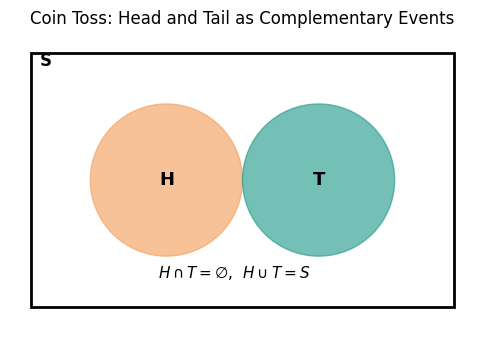

In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle

fig, ax = plt.subplots(figsize=(6, 4))
ax.add_patch(Rectangle((0, 0), 10, 6, fill=False, linewidth=2, edgecolor='black'))
ax.text(0.2, 5.7, 'S', fontsize=12, fontweight='bold')

# Complementary events for a single toss
ax.add_patch(Circle((3.2, 3.0), 1.8, color='#f4a261', alpha=0.65))
ax.add_patch(Circle((6.8, 3.0), 1.8, color='#2a9d8f', alpha=0.65))
ax.text(3.2, 3.0, 'H', ha='center', va='center', fontsize=13, fontweight='bold')
ax.text(6.8, 3.0, 'T', ha='center', va='center', fontsize=13, fontweight='bold')
ax.text(3.0, 0.7, r'$H \cap T = \emptyset$,  $H \cup T = S$', fontsize=11)

ax.set_title('Coin Toss: Head and Tail as Complementary Events')
ax.set_xlim(-0.5, 10.5)
ax.set_ylim(-0.5, 6.5)
ax.set_aspect('equal')
ax.axis('off')
plt.show()

### Venn Diagram: Coin Toss Example

For one toss, let $H$ = head and $T$ = tail. These are complementary events:

- $H \cap T = \emptyset$
- $H \cup T = S$
- $P(H) + P(T) = 1$

## Mutually Exclusive vs. Complementary Events

This is a common point of confusion. It's important to distinguish between these two concepts.

### Mutually Exclusive Events
Two events, A and B, are **mutually exclusive** if they cannot occur at the same time. Their intersection is empty.

- **Condition:** $A \cap B = \emptyset$
- **Implication:** $P(A \cap B) = 0$
- **Sum Rule:** $P(A \cup B) = P(A) + P(B)$

This does **not** mean that $P(A) + P(B) = 1$.

### Complementary Events
Two events, A and B, are **complementary** if they are mutually exclusive AND their union covers the entire sample space. B is the complement of A, often written as $A^c$.

- **Conditions:**
  1. $A \cap B = \emptyset$ (mutually exclusive)
  2. $A \cup B = S$ (exhaustive)
- **Implication:** $P(A) + P(B) = 1$, which means $P(B) = 1 - P(A)$.

In short, all complementary events are mutually exclusive, but not all mutually exclusive events are complementary.


In [5]:
# Example with a fair die
# A = {1, 2}, B = {3, 4}
# A and B are mutually exclusive, but NOT complementary

A = {1, 2}
B = {3, 4}
S = {1, 2, 3, 4, 5, 6}

P_A = len(A) / len(S)
P_B = len(B) / len(S)
P_union = len(A | B) / len(S)

print('Mutually exclusive check:', A.isdisjoint(B))
print(f'P(A) = {P_A:.3f}')
print(f'P(B) = {P_B:.3f}')
print(f'P(A) + P(B) = {P_A + P_B:.3f}')
print(f'P(A ∪ B) = {P_union:.3f}')
print(f'1 - P(A) = {1 - P_A:.3f}   <-- not equal to P(B) here')

Mutually exclusive check: True
P(A) = 0.333
P(B) = 0.333
P(A) + P(B) = 0.667
P(A ∪ B) = 0.667
1 - P(A) = 0.667   <-- not equal to P(B) here


### Venn Diagram: Fair Die Example

For the die example, $A = \{1,2\}$ and $B = \{3,4\}$ are mutually exclusive.
But they are not exhaustive because outcomes $\{5,6\}$ are outside $A \cup B$.

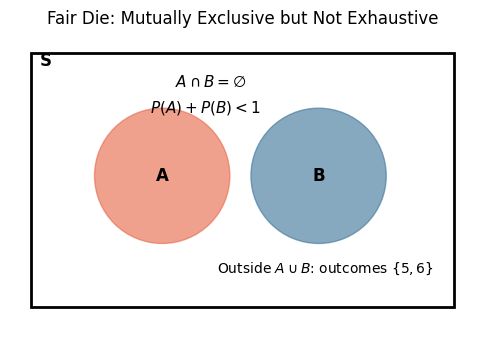

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle

fig, ax = plt.subplots(figsize=(6, 4))
ax.add_patch(Rectangle((0, 0), 10, 6, fill=False, linewidth=2, edgecolor='black'))
ax.text(0.2, 5.7, 'S', fontsize=12, fontweight='bold')

# A and B are disjoint
ax.add_patch(Circle((3.1, 3.1), 1.6, color='#e76f51', alpha=0.65))
ax.add_patch(Circle((6.8, 3.1), 1.6, color='#457b9d', alpha=0.65))
ax.text(3.1, 3.1, 'A', ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(6.8, 3.1, 'B', ha='center', va='center', fontsize=12, fontweight='bold')

# Region outside A union B represents outcomes {5,6}
ax.text(4.4, 0.8, r'Outside $A \cup B$: outcomes $\{5,6\}$', fontsize=10)
ax.text(3.4, 5.2, r'$A \cap B = \emptyset$', fontsize=11)
ax.text(2.8, 4.6, r'$P(A)+P(B) < 1$', fontsize=11)

ax.set_title('Fair Die: Mutually Exclusive but Not Exhaustive')
ax.set_xlim(-0.5, 10.5)
ax.set_ylim(-0.5, 6.5)
ax.set_aspect('equal')
ax.axis('off')
plt.show()

## Summary of Key Concepts

- **Event:** A subset of the sample space.
- **Probability:** The long-run frequency of an event, a value between 0 and 1.
- **Mutually Exclusive Events:** Cannot happen at the same time ($A \cap B = \emptyset$). Their probabilities add up when calculating the probability of their union, but do not necessarily sum to 1.
- **Complementary Events:** Are mutually exclusive and also cover all possible outcomes ($A \cup A^c = S$). Their probabilities always sum to 1.
